<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Instalación de librerías adicionales**

In [10]:
!pip install --q prophet

# **Librerías**

In [55]:
from google.colab import auth, drive, files # Librerías de Google Colab; «auth» permite autenticarse con la cuenta de Google, «drive» permite acceder al contenido de Google Drive, «file» permite interactuar con los archivos generados.
from prophet import Prophet as ph # Prophet de Meta (Facebook)
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
import matplotlib.pyplot as plt # Librería que permite generar gráficas.
import pandas as pd # Librería que permite la manipulación de dataframes.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.

# **Data frame**

In [12]:
drive.mount("/content/drive", force_remount=True) # Monta Google Drive.
wd = "/content/drive/MyDrive/Forecast_FIME/examen/" # Variable que establece el directorio de trabajo (working directory).

df_main = pd.read_csv(wd + "thelook_ecommerce.csv") # Archivo donde se encuentra la información sin transformar.
df_main["created_at"] = pd.to_datetime(df_main["created_at"], utc=True, format="mixed").dt.date # Convierte el formato de fecha UTC en ISO.

df_filtered = df_main[df_main["status"] == "Processing"]  # Filtra solo los valores que tengan el estatus "Processing".

df = df_filtered.groupby("created_at", as_index=False)["sale_price"].sum()  # Crea un nuevo conjunto de datos sumando el valor de las ventas por día.
df.rename(columns={"sale_price": "total_sales"}, inplace=True)  # Renombra la columna "sale_price" a "total_sales".

df.head() # Muestra las primeras filas del dataframe df.

Mounted at /content/drive


,created_at,total_sales
0,2019-01-12,57.000000
1,2019-01-13,115.560001
2,2019-01-16,49.500000
3,2019-01-19,215.000000
4,2019-01-22,60.570000


#**Funciones**

In [56]:
def seasonality_check(df: object, ds_name: str) :
  """
    Identifica la periodicidad de los datos en un DataFrame.

    Args:
        df (object): DataFrame que contiene los datos a analizar.
        ds_name (str): Nombre de la columna que contiene las fechas.

    Returns:
        dict: Diccionario con los parámetros booleanos de periodicidad.
  """

  # Parámetros por defecto
  day = False
  week = True
  month = True
  year = True

  # Revisa cuántos periodos contiene el dataframe.
  periods = min (
      (max(df[ds_name]) - min(df[ds_name])).days,
      df.shape[0]
  )

  if periods == 1 :
    day = True
  if periods < 7 :
    week = False
  if periods < 90 : # El rango de 90 días parece ser sugerido por el profesor.
    month = False
  if periods <= 365 :
    year = False

  dictionary = {  # Diccionario de valores booleanos con los parámetros.
      "day" : day,
      "week" : week,
      "month" : month,
      "year" : year
  }

  return dictionary

In [57]:
def real_plt(df: object, time_column_name: str, value_column_name: str, title: str) :
  """
  Grafica la serie de tiempo con los datos reales.

  Args:
      df (object): DataFrame que contiene los datos a graficar.
      time_column_name (str): Nombre de la columna que contiene las fechas.
      value_column_name (str): Nombre de la columna que contiene los valores.
      title (str): Título de la gráfica.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = px.line(df, x=time_column_name, y=value_column_name, title=title)

  fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
      buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
      ])
    )
  )

  return fig.show()

In [58]:
def real_vs_forecast_plt(real_df: object, real_time_column_name: str, real_value_column_name: str, forecast_df: object, title: str, forecast_time_column_name = "ds", forecast_value_column_name = "yhat") :
  """
  Grafica la comparativa de las series de tiempo con los datos reales y pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      real_time_column_name (str): Nombre de la columna que contiene las fechas de los datos reales.
      real_value_column_name (str): Nombre de la columna que contiene los valores reales.
      forecast_df (object): DataFrame que contiene los datos pronosticados.
      title (str): Título de la gráfica.
      forecast_time_column_name (str): Nombre de la columna que contiene las fechas de los datos pronosticados.
      forecast_value_column_name (str): Nombre de la columna que contiene los valores pronosticados.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = go.Figure()

  fig.add_trace(
      go.Scatter(
          x = forecast_df[forecast_time_column_name],
          y = forecast_df[forecast_value_column_name],
          name = "Prophet",
          line = dict(color = "#8C000F", width = 3, dash = "dash")
      )
  )

  fig.add_trace(
      go.Scatter(
          x = real_df[real_time_column_name],
          y = real_df[real_value_column_name],
          name = "Real",
          line = dict(color = "olive", width = 3, dash = "dash")
      )
  )

  fig.update_layout(
      title = title,
      xaxis_title = "Tiempo",
      yaxis_title = "Ventas"
  )

  return fig.show()

#**Parámetros Prophet**

In [59]:
dictionary_seasonality = seasonality_check(df = df, ds_name = "created_at") # Revisa la periodicidad del dataframe.

ph_parameters = { # Genera diccionado con los parámetros utilizados por Prophet
    "growth" : "linear",
    "changepoint_range" : 0.6,
    "interval_width" : 0.6,

    "daily_seasonality" : dictionary_seasonality["day"],
    "weekly_seasonality" : dictionary_seasonality["week"],
    # "monthly_seasonality" : dictionary_seasonality["month"],  # Parece que Prophet no requiere este parámetro.
    "yearly_seasonality" : dictionary_seasonality["year"],

    "seasonality_mode" : "multiplicative",
    "seasonality_prior_scale" : 1,
    "holidays_prior_scale" : 1,
    "changepoint_prior_scale" : 1
}

#**Grafica estado actual**

In [60]:
real_plt(df = df, time_column_name = "created_at", value_column_name = "total_sales", title = "Ventas")

#**Entrenamiento del modelo**

In [61]:
data_model = df.rename(columns={"created_at": "ds", "total_sales": "y"})  # Cambia el nombre de las columnas por aquellas que requiere Prophet para trabajar y crea un nuevo data frame con el nombre de estas columnas.

model = ph(**ph_parameters) # Crea un modelo de Prophet con los parámetros establecidos.
model.fit(data_model) # Agrega los datos al modelo de Prophet.

future_dates = model.make_future_dataframe(periods=90, freq="d")  # Establece los parámetros para un pronóstico a 90 días.
forecast = model.predict(future_dates)  # Crea el propóstico.

DEBUG:cmdstanpy:input tempfile: /tmp/tmpb_9czfli/ykp588w9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb_9czfli/kjuvayu2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=62073', 'data', 'file=/tmp/tmpb_9czfli/ykp588w9.json', 'init=/tmp/tmpb_9czfli/kjuvayu2.json', 'output', 'file=/tmp/tmpb_9czfli/prophet_modelw5oodj4c/prophet_model-20250308062328.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:23:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:23:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


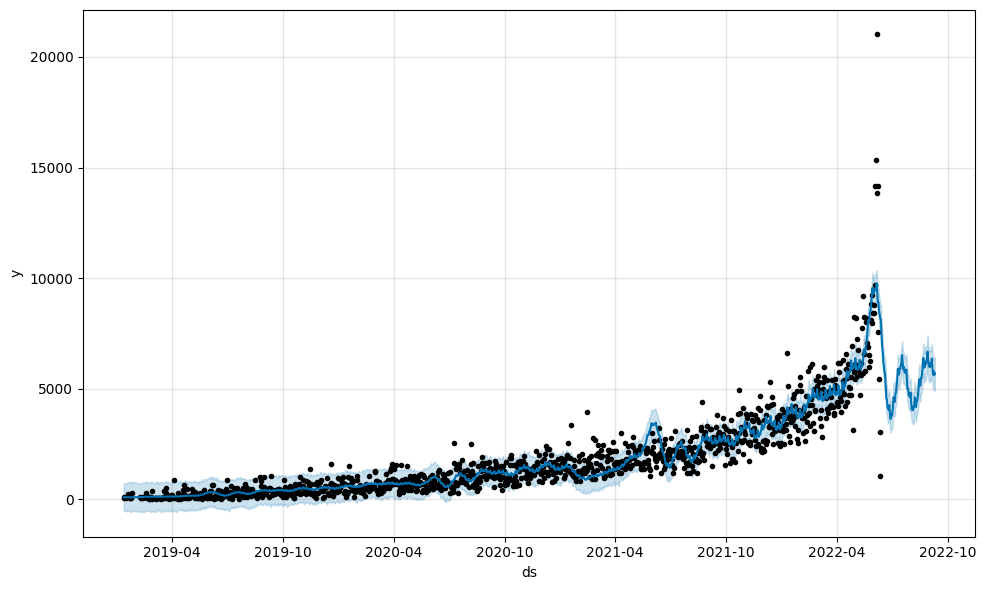

In [62]:
real_vs_forecast_plt(real_df = df, real_time_column_name = "created_at", real_value_column_name = "total_sales", forecast_df = forecast, title="Ventas reales vs Prophet")  # Crea la gráfica comparativa de las ventas reales vs el pronóstico.
model.plot(forecast)
plt.show()

#**Componentes**

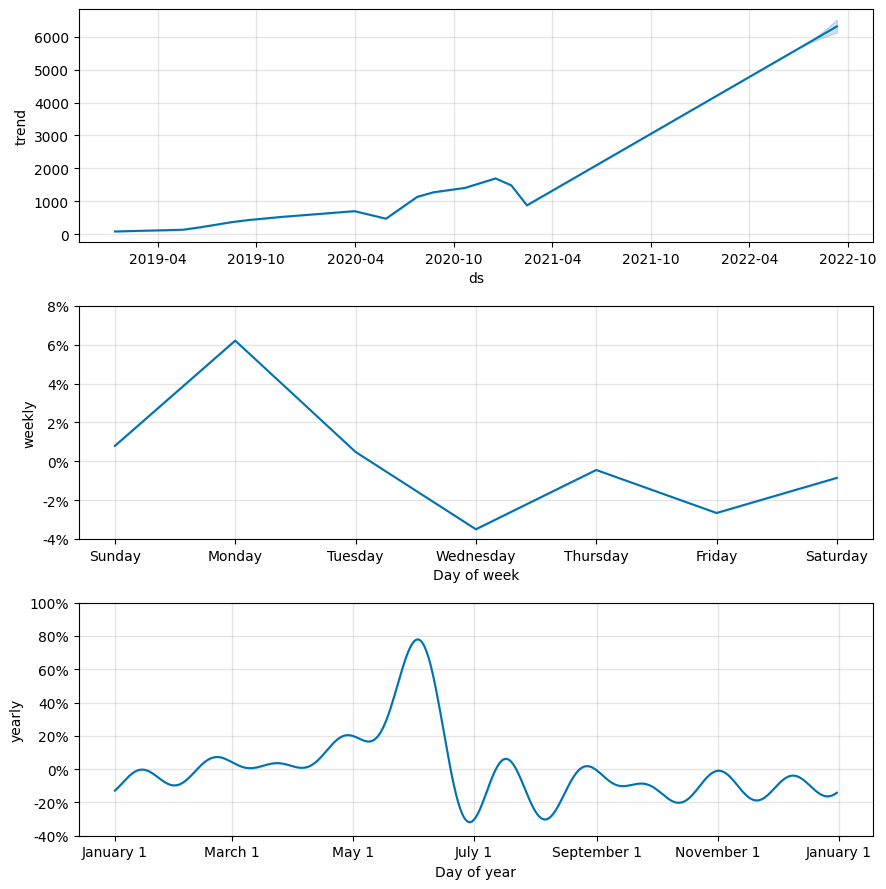

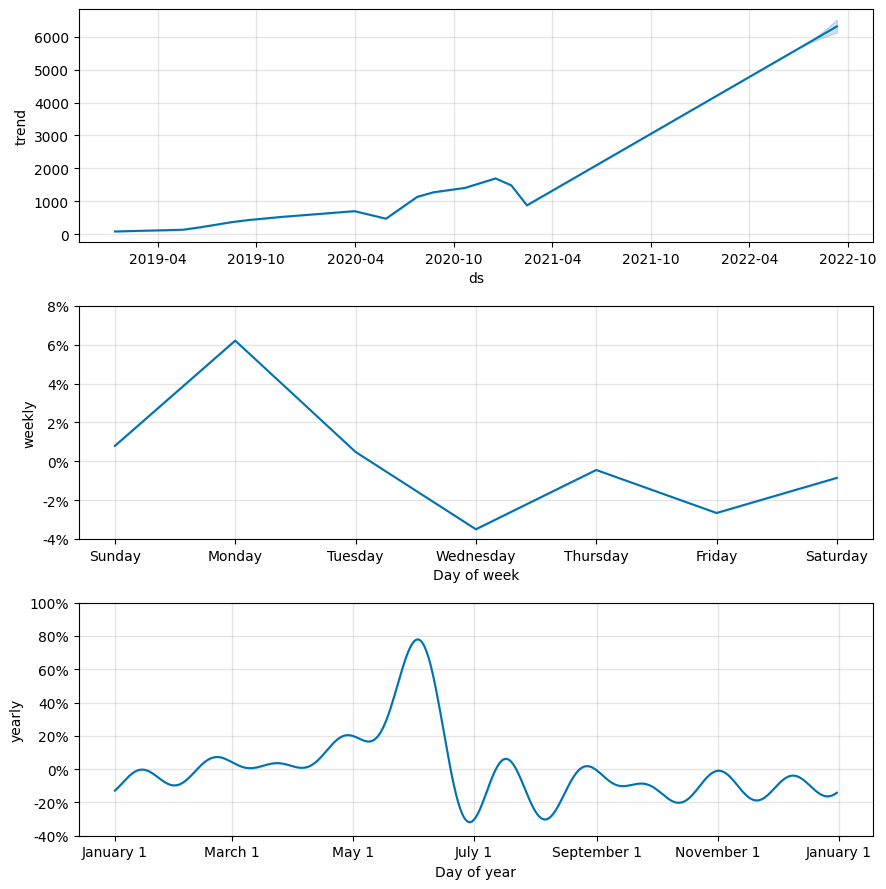

In [52]:
plot_plotly(model, forecast)
model.plot_components(forecast)

#**Descarga de datos de Google Colab**

In [53]:
forecast.to_csv("forecast.csv")
files.download("forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>